In [1]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Reshape, Add, Embedding
)
import keras_tuner as kt

In [3]:
df = pd.read_csv("enhanced_dataset.csv")
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,81.0,85.142857,5.843189,9.0,0.0,330.0,0.0,23.027933,15.102065,-2.538462
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,91.0,85.714286,6.651172,4.0,330.0,285.6,300.0,23.483530,15.023077,-3.503846
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,91.0,85.571429,6.528327,-1.0,288.0,270.6,480.0,23.107410,1.521747,-3.942308
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,80.0,87.571429,6.679749,14.0,460.0,329.0,1200.0,22.867111,1.978576,-4.903846
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,84.0,89.428571,7.299706,13.0,0.0,524.4,0.0,23.229702,2.003212,-1.792308


**Predicting weather_condition only sliding _window 10 ----> 3 days forecast**

In [25]:
class TimeSeriesTransformerModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Time Series Transformer model with advanced class imbalance handling
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Transformer-specific parameters
        self.d_model = 128  # Model dimension
        self.num_heads = 8  # Number of attention heads
        self.num_layers = 4  # Number of transformer layers
        self.ff_dim = 256   # Feed-forward dimension
        
        # Same proven thresholds from your LSTM model
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        
    def positional_encoding(self, length, depth):
        """
        Create positional encoding for transformer
        """
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        
        angle_rads = positions * (1 / (10000**depths))
        
        pos_encoding = np.concatenate([
            np.sin(angle_rads),
            np.cos(angle_rads)
        ], axis=-1)
        
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing with three-tier class categorization (same as LSTM)"""
        print("🧹 Enhanced preprocessing for Transformer...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        
        # 🔄 Merge specific weather classes (same strategy)
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        """
        Same improved sliding window strategy as LSTM model
        """
        print(f"\n🪟 Creating improved sliding windows for Transformer...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """
        Same targeted augmentation strategy as LSTM model
        """
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """
        Same focal loss implementation as LSTM model
        """
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def transformer_encoder_layer(self, inputs, head_size, num_heads, ff_dim, dropout=0.1):
        """
        Single Transformer encoder layer
        """
        # Multi-head self-attention
        attention_output = MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=head_size,
            dropout=dropout
        )(inputs, inputs)
        
        # Dropout and residual connection
        attention_output = Dropout(dropout)(attention_output)
        attention_output = Add()([inputs, attention_output])
        attention_output = LayerNormalization(epsilon=1e-6)(attention_output)
        
        # Feed-forward network
        ffn_output = Dense(ff_dim, activation="relu")(attention_output)
        ffn_output = Dropout(dropout)(ffn_output)
        ffn_output = Dense(inputs.shape[-1])(ffn_output)
        
        # Dropout and residual connection
        ffn_output = Dropout(dropout)(ffn_output)
        ffn_output = Add()([attention_output, ffn_output])
        ffn_output = LayerNormalization(epsilon=1e-6)(ffn_output)
        
        return ffn_output
    
    def build_transformer_model(self, input_shape, num_classes):
        """
        Build Time Series Transformer model
        """
        print(f"Building Transformer model with input shape: {input_shape}")
        
        # Input layer
        inputs = Input(shape=input_shape)
        
        # Project input features to model dimension
        x = Dense(self.d_model, activation='relu')(inputs)
        
        # Add positional encoding
        pos_encoding = self.positional_encoding(self.sequence_length, self.d_model)
        x = x + pos_encoding
        
        # Dropout after positional encoding
        x = Dropout(0.1)(x)
        
        # Stack transformer encoder layers
        for i in range(self.num_layers):
            x = self.transformer_encoder_layer(
                x, 
                head_size=self.d_model // self.num_heads,
                num_heads=self.num_heads,
                ff_dim=self.ff_dim,
                dropout=0.1
            )
        
        # Global average pooling to get sequence representation
        x = GlobalAveragePooling1D()(x)
        
        # Additional dense layers for final processing
        x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
        x = Dropout(0.3)(x)
        
        x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
        x = Dropout(0.2)(x)
        
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.1)(x)
        
        # Output layer - predict all forecast steps at once
        outputs = Dense(self.forecast_horizon * num_classes, activation='softmax')(x)
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        outputs = Reshape((self.forecast_horizon, num_classes))(outputs)
        
        model = Model(inputs=inputs, outputs=outputs)
        return model
    
    def train_transformer_model(self, use_augmentation=True):
        """
        Train the Time Series Transformer model
        """
        print("\n" + "="*70)
        print("TRAINING TIME SERIES TRANSFORMER + REBALANCING MODEL")
        print("="*70)
        
        # Create improved sliding windows (same strategy as LSTM)
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile Transformer model
        self.model = self.build_transformer_model((self.sequence_length, X.shape[2]), num_classes)
        
        # Print model summary
        print("\nTransformer Model Architecture:")
        self.model.summary()
        
        # Use focal loss for better minority class handling
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),  # Lower LR for Transformer
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining Transformer model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=16,  # Smaller batch size for Transformer
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating Transformer model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_transformer_results(y_true, y_pred, history)
    
    def evaluate_transformer_results(self, y_true, y_pred, history):
        """
        Comprehensive evaluation with class-tier analysis (same as LSTM)
        """
        print("\n" + "="*70)
        print("TIME SERIES TRANSFORMER + REBALANCING RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                     target_names=target_names, 
                                     zero_division=0,
                                     output_dict=True)
        print(classification_report(y_true[:, 0], y_pred[:, 0], 
                                  target_names=target_names, 
                                  zero_division=0))
        
        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Attention analysis (Transformer-specific)
        print(f"\n🔍 TRANSFORMER ATTENTION ANALYSIS:")
        print("-" * 50)
        print(f"  Model Dimension (d_model): {self.d_model}")
        print(f"  Number of Attention Heads: {self.num_heads}")
        print(f"  Number of Transformer Layers: {self.num_layers}")
        print(f"  Feed-Forward Dimension: {self.ff_dim}")
        print(f"  Total Parameters: {self.model.count_params():,}")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        """
        Enhanced prediction with confidence analysis
        """
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy
    

In [26]:
def run_transformer_weather_forecasting(df, use_augmentation=True):
    """Run Time Series Transformer + rebalancing weather forecasting"""
    print("🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting")
    print("=" * 70)
    
    # Initialize Transformer model
    model = TimeSeriesTransformerModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train Transformer model with rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_transformer_model(use_augmentation=use_augmentation)
    
    print(f"\n🎯 FINAL TRANSFORMER RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
transformer_model, acc, daily_accs, y_true, y_pred, history = run_transformer_weather_forecasting(df)

🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing for Transformer...
Original class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Class percentages:
weather_condition
Cloudy ☁️             36.78
Partly Clear 🌤/⛅      21.60
Light Drizzle 🌦       14.56
Clear Sky ☀️          13.52
Moderate Drizzle 🌧     5.64
Light Rain 🌦           3.57
Moderate Rain 🌧        2.36
Heavy Drizzle 🌧        1.84
Heavy Rain 🌧           0.14
Name: count, dtype: float64

Minority classes (<8.0%): ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes (8.0%-20.0%): ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes (>20.0%): ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAINING TIM

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 10, 155)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 10, 128)   │     19,968 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 10, 128)   │          0 │ dense_53[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_77          │ (None, 10, 128)   │          0 │ add_37[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ dropout_77[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_77[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_79          │ (None, 10, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_38 (Add)        │ (None, 10, 128)   │          0 │ dropout_77[0][0], │
│                     │                   │            │ dropout_79[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_38[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 10, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_80          │ (None, 10, 256)   │          0 │ dense_54[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 10, 128)   │     32,896 │ dropout_80[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_81          │ (None, 10, 128)   │          0 │ dense_55[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_39 (Add)        │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_81[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_39[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_83          │ (None, 10, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_40 (Add)        │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_83[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_40[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 783,643 (2.99 MB)

 Trainable params: 783,643 (2.99 MB)

 Non-trainable params: 0 (0.00 B)


Training Transformer model...
Epoch 1/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 60s 19ms/step - accuracy: 0.2208 - loss: 1.1270 - val_accuracy: 0.2505 - val_loss: 0.8772 - learning_rate: 1.0000e-04
Epoch 2/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2472 - loss: 0.8522 - val_accuracy: 0.2619 - val_loss: 0.7716 - learning_rate: 1.0000e-04
Epoch 3/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2690 - loss: 0.7596 - val_accuracy: 0.2881 - val_loss: 0.7103 - learning_rate: 1.0000e-04
Epoch 4/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2913 - loss: 0.7063 - val_accuracy: 0.3155 - val_loss: 0.6724 - learning_rate: 1.0000e-04
Epoch 5/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.3164 - loss: 0.6730 - val_accuracy: 0.3500 - val_loss: 0.6425 - learning_rate: 1.0000e-04
Epoch 6/200
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3415 - loss: 0.6488 - val_accuracy: 0.3735 - val_loss: 0.6167 - learning_rate: 1.0000e-04
Epo


🔮 Making 3-day Transformer weather forecast...
--------------------------------------------------
📅 3-Day Transformer Weather Forecast:
┌──────────────────────────────────────────────────────────────────────┐
│                     TRANSFORMER WEATHER FORECAST                     │
├───────────────┬─────────────────────────┬────────────┬──────────────┤
│  Day (Date)   │        Condition        │ Confidence │ Uncertainty  │
├───────────────┼─────────────────────────┼────────────┼──────────────┤
│🔴 Thu (05-01)  │    Partly Clear 🌤/⛅     │   0.306    │    0.231     │
│🔴 Fri (05-02)  │        Cloudy ☁️        │   0.282    │    0.218     │
│🔴 Sat (05-03)  │        Cloudy ☁️        │   0.301    │    0.217     │
└───────────────┴─────────────────────────┴────────────┴──────────────┘


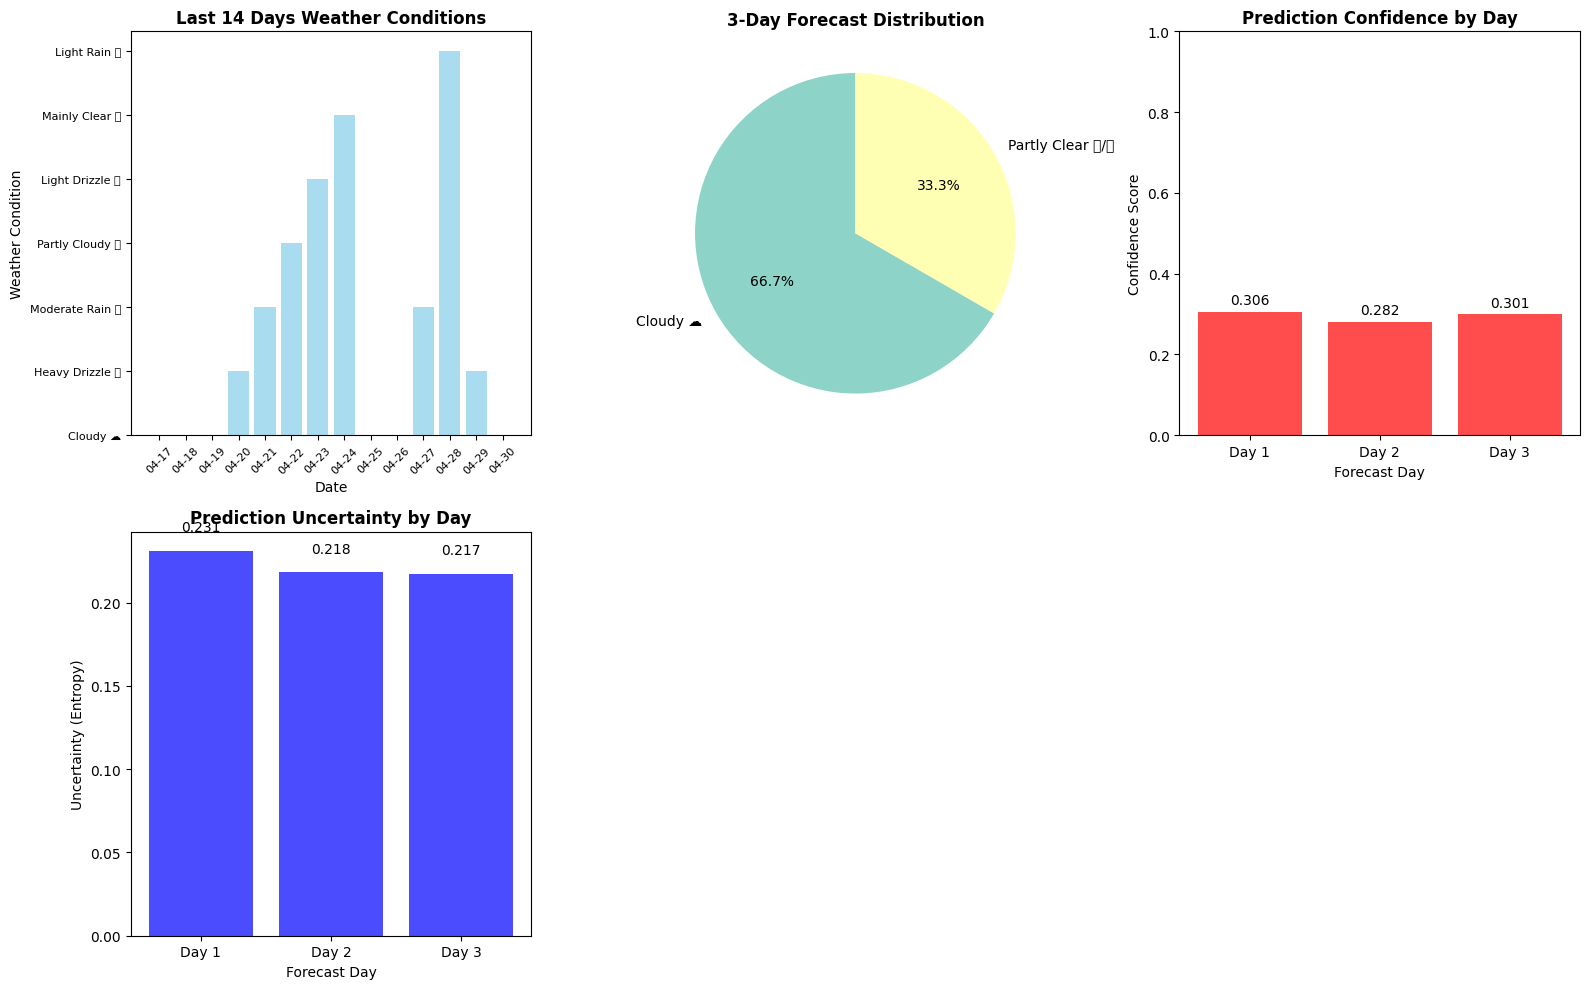


📊 TRANSFORMER PREDICTION SUMMARY:
Average Confidence: 0.296
Average Uncertainty: 0.222
Most Confident Day: Day 1 (0.306)
Least Confident Day: Day 2 (0.282)
Most Uncertain Day: Day 1 (0.231)
Least Uncertain Day: Day 3 (0.217)


In [30]:
def make_transformer_predictions_and_visualize(model, df):
    """Make Transformer predictions and create advanced visualizations"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    
    print("\n🔮 Making 3-day Transformer weather forecast...")
    print("-" * 50)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week (Transformer returns uncertainties too)
        predicted_conditions, confidence_scores, uncertainties = model.predict_next_week(recent_data)
        
        print("📅 3-Day Transformer Weather Forecast:")
        # Get last date in the dataset and generate next 4 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        # Enhanced prediction display with uncertainty
        print("┌" + "─" * 70 + "┐")
        print("│{:^70}│".format("TRANSFORMER WEATHER FORECAST"))
        print("├" + "─" * 15 + "┬" + "─" * 25 + "┬" + "─" * 12 + "┬" + "─" * 14 + "┤")
        print("│{:^15}│{:^25}│{:^12}│{:^14}│".format("Day (Date)", "Condition", "Confidence", "Uncertainty"))
        print("├" + "─" * 15 + "┼" + "─" * 25 + "┼" + "─" * 12 + "┼" + "─" * 14 + "┤")
        
        for (day, date), condition, confidence, uncertainty in zip(days_and_dates, predicted_conditions, confidence_scores, uncertainties):
            # Color coding based on confidence
            if confidence > 0.8:
                status = "🟢"  # High confidence
            elif confidence > 0.6:
                status = "🟡"  # Medium confidence
            else:
                status = "🔴"  # Low confidence
                
            day_short = day[:3]
            date_short = date[5:]  # MM-DD format
            condition_short = condition[:22] + "..." if len(condition) > 22 else condition
            
            print("│{}{:^14}│{:^25}│{:^12.3f}│{:^14.3f}│".format(
                status, f"{day_short} ({date_short})", condition_short, confidence, uncertainty))
        
        print("└" + "─" * 15 + "┴" + "─" * 25 + "┴" + "─" * 12 + "┴" + "─" * 14 + "┘")
        
        # Enhanced visualization with uncertainty
        plt.figure(figsize=(16, 10))
        
        # Plot 1: Recent actual weather conditions
        plt.subplot(2, 3, 1)
        recent_df = df[['date', 'weather_condition']].tail(14)
        recent_df['date'] = pd.to_datetime(recent_df['date'])
        bars = plt.bar(range(len(recent_df)), recent_df['weather_condition'].astype(str), 
                      color='skyblue', alpha=0.7)
        plt.xticks(range(len(recent_df)), 
                  recent_df['date'].dt.strftime('%m-%d'), rotation=45)
        plt.title('Last 14 Days Weather Conditions', fontsize=12, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        
        # Plot 2: Forecast distribution
        plt.subplot(2, 3, 2)
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        colors = plt.cm.Set3(range(len(forecast_counts)))
        wedges, texts, autotexts = plt.pie(forecast_counts.values, labels=forecast_counts.index, 
                                          autopct='%1.1f%%', colors=colors, startangle=90)
        plt.title('3-Day Forecast Distribution', fontsize=12, fontweight='bold')
        
        # Plot 3: Confidence scores over forecast days
        plt.subplot(2, 3, 3)
        days_short = [f"Day {i+1}" for i in range(3)]
        bars = plt.bar(days_short, confidence_scores, 
                      color=['green' if c > 0.8 else 'orange' if c > 0.6 else 'red' for c in confidence_scores],
                      alpha=0.7)
        plt.title('Prediction Confidence by Day', fontsize=12, fontweight='bold')
        plt.xlabel('Forecast Day')
        plt.ylabel('Confidence Score')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, conf in zip(bars, confidence_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{conf:.3f}', ha='center', va='bottom', fontsize=10)
        
        # Plot 4: Uncertainty analysis
        plt.subplot(2, 3, 4)
        bars = plt.bar(days_short, uncertainties,
                      color=['blue' if u < 0.3 else 'purple' if u < 0.6 else 'red' for u in uncertainties],
                      alpha=0.7)
        plt.title('Prediction Uncertainty by Day', fontsize=12, fontweight='bold')
        plt.xlabel('Forecast Day')
        plt.ylabel('Uncertainty (Entropy)')

        # Add value labels on bars
        for bar, unc in zip(bars, uncertainties):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{unc:.3f}', ha='center', va='bottom', fontsize=10)
        
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n📊 TRANSFORMER PREDICTION SUMMARY:")
        print(f"Average Confidence: {np.mean(confidence_scores):.3f}")
        print(f"Average Uncertainty: {np.mean(uncertainties):.3f}")
        print(f"Most Confident Day: Day {np.argmax(confidence_scores) + 1} ({max(confidence_scores):.3f})")
        print(f"Least Confident Day: Day {np.argmin(confidence_scores) + 1} ({min(confidence_scores):.3f})")
        print(f"Most Uncertain Day: Day {np.argmax(uncertainties) + 1} ({max(uncertainties):.3f})")
        print(f"Least Uncertain Day: Day {np.argmin(uncertainties) + 1} ({min(uncertainties):.3f})")
        
        return predicted_conditions, confidence_scores, uncertainties
        
    except Exception as e:
        print(f"❌ Transformer prediction error: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

# Usage:
predictions, confidences, uncertainties = make_transformer_predictions_and_visualize(transformer_model, df)

In [31]:
def evaluate_results(self, y_true, y_pred, history=None):
    """
    Comprehensive evaluation with class-tier analysis and visualizations
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import numpy as np
    
    print("\n" + "="*70)
    print("SLIDING WINDOW + REBALANCING RESULTS")
    print("="*70)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    print(f"Overall Test Accuracy: {overall_acc:.4f}")
    
    # Daily accuracies
    daily_accuracies = []
    for day in range(self.forecast_horizon):
        day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
        daily_accuracies.append(day_acc)
        print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
    # Detailed classification report for Day 1
    print(f"\nDetailed Classification Report (Day 1):")
    print("-" * 70)
    target_names = self.label_encoder.classes_
    report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                 target_names=target_names, 
                                 zero_division=0, 
                                 output_dict=True)
    print(classification_report(y_true[:, 0], y_pred[:, 0], 
                              target_names=target_names, 
                              zero_division=0))
    
    # Class-tier performance analysis
    print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
    print("="*70)
    
    for tier_name, class_list in [
        ("MINORITY", self.minority_classes),
        ("BALANCED", self.balanced_classes), 
        ("MAJORITY", self.majority_classes)
    ]:
        print(f"\n{tier_name} CLASSES:")
        print("-" * 40)
        tier_f1_scores = []
        tier_recalls = []
        tier_precisions = []
        
        for class_name in class_list:
            if class_name in report:
                metrics = report[class_name]
                f1 = metrics['f1-score']
                precision = metrics['precision']
                recall = metrics['recall']
                support = metrics['support']
                
                tier_f1_scores.append(f1)
                tier_recalls.append(recall)
                tier_precisions.append(precision)
                
                status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
        
        if tier_f1_scores:
            avg_f1 = np.mean(tier_f1_scores)
            avg_precision = np.mean(tier_precisions)
            avg_recall = np.mean(tier_recalls)
            print(f"\n  📊 {tier_name} AVERAGES:")
            print(f"     Precision: {avg_precision:.4f}")
            print(f"     Recall: {avg_recall:.4f}")
            print(f"     F1-Score: {avg_f1:.4f}")
    
    # Problem class identification
    print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
    print("-" * 50)
    struggling_classes = []
    for class_name in target_names:
        if class_name in report and report[class_name]['f1-score'] < 0.2:
            struggling_classes.append(class_name)
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
    
    if not struggling_classes:
        print("  🎉 No classes with F1 < 0.2!")
    
    # Success stories
    print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
    print("-" * 50)
    success_classes = []
    for class_name in target_names:
        if class_name in report and report[class_name]['f1-score'] > 0.5:
            success_classes.append(class_name)
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
    
    # Enhanced visualizations
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    
    # 1. Daily accuracies with trend line
    axes[0, 0].bar(range(1, self.forecast_horizon + 1), daily_accuracies, 
                   color=['#2E8B57' if acc > 0.7 else '#FF6B6B' if acc < 0.5 else '#4ECDC4' 
                          for acc in daily_accuracies])
    axes[0, 0].plot(range(1, self.forecast_horizon + 1), daily_accuracies, 
                    'ro-', linewidth=2, markersize=8, alpha=0.7)
    axes[0, 0].set_title('Accuracy by Forecast Day', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Day')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)
    for i, acc in enumerate(daily_accuracies):
        axes[0, 0].text(i+1, acc+0.02, f'{acc:.3f}', ha='center', fontweight='bold')
    
    # 2. Enhanced confusion matrix for Day 1
    cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
    mask = cm == 0
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, 
                ax=axes[0, 1], mask=mask, cbar_kws={'label': 'Count'})
    axes[0, 1].set_title('Confusion Matrix (Day 1)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    plt.setp(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
    plt.setp(axes[0, 1].get_yticklabels(), rotation=0)
    
    # 3. Class-tier F1 scores comparison
    tier_data = {'Tier': [], 'Class': [], 'F1-Score': [], 'Support': []}
    for tier_name, class_list in [("Minority", self.minority_classes),
                                  ("Balanced", self.balanced_classes), 
                                  ("Majority", self.majority_classes)]:
        for class_name in class_list:
            if class_name in report:
                tier_data['Tier'].append(tier_name)
                tier_data['Class'].append(class_name[:15] + '...' if len(class_name) > 15 else class_name)
                tier_data['F1-Score'].append(report[class_name]['f1-score'])
                tier_data['Support'].append(report[class_name]['support'])
    
    # Create tier comparison bar plot
    tier_colors = {'Minority': '#FF6B6B', 'Balanced': '#4ECDC4', 'Majority': '#2E8B57'}
    x_pos = np.arange(len(tier_data['Class']))
    colors = [tier_colors[tier] for tier in tier_data['Tier']]
    
    bars = axes[1, 0].bar(x_pos, tier_data['F1-Score'], color=colors, alpha=0.7)
    axes[1, 0].set_title('F1-Scores by Class Tier', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Classes')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(tier_data['Class'], rotation=45, ha='right')
    axes[1, 0].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Good (>0.5)')
    axes[1, 0].axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, label='Poor (<0.2)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, f1_score in zip(bars, tier_data['F1-Score']):
        if f1_score > 0.05:  # Only show label if bar is visible
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{f1_score:.2f}', ha='center', va='bottom', fontsize=8)
    
    # 4. Sample predictions vs actual (enhanced)
    sample_size = min(3, len(y_true))
    x_pos = np.arange(self.forecast_horizon)
    width = 0.35
    
    # Use the remaining subplot for the first sample
    axes[1, 1].bar(x_pos - width/2, y_true[0], width, label='Actual', alpha=0.7, color='skyblue')
    axes[1, 1].bar(x_pos + width/2, y_pred[0], width, label='Predicted', alpha=0.7, color='orange')
    axes[1, 1].set_title('Prediction vs Actual - Sample Sequence 1', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Day')
    axes[1, 1].set_ylabel('Weather Code')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([f'Day {d+1}' for d in x_pos])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 5. Prediction accuracy heatmap across all days
    day_class_accuracy = np.zeros((len(target_names), self.forecast_horizon))
    for day in range(self.forecast_horizon):
        for i, class_name in enumerate(target_names):
            class_mask = (y_true[:, day] == i)
            if np.sum(class_mask) > 0:
                day_class_accuracy[i, day] = np.mean(y_pred[class_mask, day] == y_true[class_mask, day])
    
    sns.heatmap(day_class_accuracy, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=[f'Day {d+1}' for d in range(self.forecast_horizon)],
                yticklabels=target_names, ax=axes[2, 0],
                cbar_kws={'label': 'Accuracy'})
    axes[2, 0].set_title('Class-wise Accuracy Across Forecast Days', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Forecast Day')
    axes[2, 0].set_ylabel('Weather Condition')
    plt.setp(axes[2, 0].get_yticklabels(), rotation=0)
    
    # 6. Training history (if available)
    if history is not None:
        axes[2, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
        axes[2, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
        axes[2, 1].set_title('Training History', fontsize=12, fontweight='bold')
        axes[2, 1].set_xlabel('Epoch')
        axes[2, 1].set_ylabel('Accuracy')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        
        # Add loss on secondary y-axis
        ax2 = axes[2, 1].twinx()
        ax2.plot(history.history['loss'], '--', color='red', alpha=0.7, label='Training Loss')
        ax2.plot(history.history['val_loss'], '--', color='orange', alpha=0.7, label='Validation Loss')
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right')
    else:
        axes[2, 1].text(0.5, 0.5, 'No training history available', 
                       transform=axes[2, 1].transAxes, ha='center', va='center', 
                       fontsize=14, style='italic')
        axes[2, 1].set_title('Training History', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Enhanced sample predictions display
    print(f"\n📊 DETAILED SAMPLE PREDICTIONS:")
    print("="*70)
    sample_size = min(3, len(y_true))
    for i in range(sample_size):
        actual_conditions = self.label_encoder.inverse_transform(y_true[i])
        pred_conditions = self.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\nSequence {i+1}:")
        print("-" * 50)
        matches = 0
        for day in range(self.forecast_horizon):
            match_status = "✅" if actual_conditions[day] == pred_conditions[day] else "❌"
            if actual_conditions[day] == pred_conditions[day]:
                matches += 1
            print(f"  Day {day+1}: {match_status} Actual='{actual_conditions[day]}' | Predicted='{pred_conditions[day]}'")
        
        sequence_accuracy = matches / self.forecast_horizon
        print(f"  📈 Sequence Accuracy: {sequence_accuracy:.2%} ({matches}/{self.forecast_horizon})")
    
    # Summary metrics
    print(f"\n🎯 FINAL PERFORMANCE SUMMARY:")
    print("="*70)
    
    minority_f1_scores = []
    balanced_f1_scores = []
    majority_f1_scores = []
    
    for class_name in self.minority_classes:
        if class_name in report:
            minority_f1_scores.append(report[class_name]['f1-score'])
    
    for class_name in self.balanced_classes:
        if class_name in report:
            balanced_f1_scores.append(report[class_name]['f1-score'])
            
    for class_name in self.majority_classes:
        if class_name in report:
            majority_f1_scores.append(report[class_name]['f1-score'])
    
    print(f"📊 Overall Test Accuracy: {overall_acc:.4f}")
    print(f"📊 Average Daily Accuracy: {np.mean(daily_accuracies):.4f}")
    if minority_f1_scores:
        print(f"🎯 Average Minority Class F1: {np.mean(minority_f1_scores):.4f}")
    if balanced_f1_scores:
        print(f"⚖️  Average Balanced Class F1: {np.mean(balanced_f1_scores):.4f}")
    if majority_f1_scores:
        print(f"📈 Average Majority Class F1: {np.mean(majority_f1_scores):.4f}")
    
    # Model complexity info
    if hasattr(self, 'model') and self.model is not None:
        total_params = self.model.count_params()
        print(f"🔧 Model Parameters: {total_params:,}")
    
    return overall_acc, daily_accuracies, history, y_true, y_pred

# This will work with the enhanced method
overall_acc, daily_accuracies, history, y_true, y_pred = transformer_model.evaluate_transformer_results(y_true, y_pred, history)


TIME SERIES TRANSFORMER + REBALANCING RESULTS
Overall Test Accuracy: 0.8768
Day 1 accuracy: 0.8767
Day 2 accuracy: 0.8849
Day 3 accuracy: 0.8689

Detailed Classification Report (Day 1):
----------------------------------------------------------------------
                    precision    recall  f1-score   support

      Clear Sky ☀️       0.65      0.70      0.68       249
         Cloudy ☁️       0.86      0.85      0.86      1299
   Heavy Drizzle 🌧       0.95      0.95      0.95       253
      Heavy Rain 🌧       1.00      0.95      0.97        20
   Light Drizzle 🌦       0.90      0.88      0.89       932
      Light Rain 🌦       0.94      0.97      0.96       514
Moderate Drizzle 🌧       0.95      0.96      0.96       759
   Moderate Rain 🌧       0.94      0.95      0.94       365
  Partly Clear 🌤/⛅       0.75      0.73      0.74       620

          accuracy                           0.88      5011
         macro avg       0.88      0.88      0.88      5011
      weighted avg  

In [32]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    """
    Enhanced display of actual vs predicted weather conditions with comprehensive analysis
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import Counter
    
    print("🌤️  ENHANCED WEATHER CONDITION PREDICTIONS")
    print("=" * 80)
    
    sample_size = min(num_samples, len(y_true))
    
    # Class-tier mapping for enhanced analysis
    class_tier_map = {}
    for class_name in model.minority_classes:
        class_tier_map[class_name] = "Minority"
    for class_name in model.balanced_classes:
        class_tier_map[class_name] = "Balanced"
    for class_name in model.majority_classes:
        class_tier_map[class_name] = "Majority"
    
    # Track prediction patterns
    prediction_analysis = {
        'perfect_sequences': 0,
        'good_sequences': 0,  # >=75% accuracy
        'poor_sequences': 0,  # <50% accuracy
        'minority_successes': 0,
        'minority_attempts': 0,
        'transition_predictions': []
    }
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)
        
        # Enhanced table format with confidence indicators
        print(f"{'Day':>4} | {'Actual Weather':^25} | {'Predicted Weather':^25} | {'Match':^6} | {'Tier':^8}")
        print("-" * 85)
        
        matches = 0
        sequence_has_minority = False
        
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            
            # Get class tier for actual condition
            tier = class_tier_map.get(actual, "Unknown")
            tier_color = "🔴" if tier == "Minority" else "🟡" if tier == "Balanced" else "🟢"
            
            # Track minority class performance
            if tier == "Minority":
                sequence_has_minority = True
                prediction_analysis['minority_attempts'] += 1
                if actual == predicted:
                    prediction_analysis['minority_successes'] += 1
            
            if actual == predicted:
                matches += 1
                
            # Truncate long weather names for display
            actual_display = actual[:23] + ".." if len(actual) > 25 else actual
            pred_display = predicted[:23] + ".." if len(predicted) > 25 else predicted
            
            print(f"{day+1:>4} | {actual_display:^25} | {pred_display:^25} | {match:^6} | {tier_color}{tier[:7]:^7}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 85)
        
        # Sequence quality assessment
        if accuracy == 1.0:
            quality = "🎯 PERFECT"
            prediction_analysis['perfect_sequences'] += 1
        elif accuracy >= 0.75:
            quality = "✅ GOOD"
            prediction_analysis['good_sequences'] += 1
        elif accuracy >= 0.5:
            quality = "⚠️  FAIR"
        else:
            quality = "❌ POOR"
            prediction_analysis['poor_sequences'] += 1
        
        minority_indicator = " 🔴 (Contains Minority)" if sequence_has_minority else ""
        print(f"Sequence Quality: {quality} - {matches}/{model.forecast_horizon} ({accuracy:.1%}){minority_indicator}")
        
        # Analyze weather transitions
        if model.forecast_horizon > 1:
            transitions = []
            for day in range(model.forecast_horizon - 1):
                if actual_conditions[day] != actual_conditions[day + 1]:
                    transition_actual = f"{actual_conditions[day]} → {actual_conditions[day + 1]}"
                    transition_pred = f"{pred_conditions[day]} → {pred_conditions[day + 1]}"
                    transition_correct = transition_actual == transition_pred
                    transitions.append((transition_actual, transition_pred, transition_correct))
            
            if transitions:
                print("🔄 Weather Transitions:")
                for j, (t_actual, t_pred, t_correct) in enumerate(transitions):
                    status = "✅" if t_correct else "❌"
                    print(f"   {status} Day {j+1}→{j+2}: {t_actual[:40]}...")
                    if not t_correct:
                        print(f"      Predicted: {t_pred[:40]}...")
    
    # Enhanced overall statistics
    print(f"\n📊 COMPREHENSIVE PREDICTION ANALYSIS:")
    print("=" * 80)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"📈 Basic Metrics:")
    print(f"   Total Predictions: {total_predictions:,}")
    print(f"   Correct Predictions: {correct_predictions:,}")
    print(f"   Overall Accuracy: {overall_accuracy:.3f} ({overall_accuracy:.1%})")
    
    # Sequence quality distribution
    total_sequences = sample_size
    print(f"\n🎯 Sequence Quality Distribution (from {total_sequences} samples):")
    print(f"   Perfect Sequences (100%): {prediction_analysis['perfect_sequences']} ({prediction_analysis['perfect_sequences']/total_sequences:.1%})")
    print(f"   Good Sequences (≥75%): {prediction_analysis['good_sequences']} ({prediction_analysis['good_sequences']/total_sequences:.1%})")
    print(f"   Poor Sequences (<50%): {prediction_analysis['poor_sequences']} ({prediction_analysis['poor_sequences']/total_sequences:.1%})")
    
    # Minority class performance
    if prediction_analysis['minority_attempts'] > 0:
        minority_success_rate = prediction_analysis['minority_successes'] / prediction_analysis['minority_attempts']
        print(f"\n🔴 Minority Class Performance:")
        print(f"   Minority Predictions: {prediction_analysis['minority_attempts']}")
        print(f"   Minority Successes: {prediction_analysis['minority_successes']}")
        print(f"   Minority Success Rate: {minority_success_rate:.3f} ({minority_success_rate:.1%})")
    
    # Per-day accuracy with trend analysis
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 50)
    daily_accuracies = []
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        daily_accuracies.append(day_accuracy)
        
        # Trend indicator
        if day > 0:
            trend = "📈" if day_accuracy > daily_accuracies[day-1] else "📉" if day_accuracy < daily_accuracies[day-1] else "➡️"
        else:
            trend = "🎯"
        
        quality_indicator = "🟢" if day_accuracy > 0.8 else "🟡" if day_accuracy > 0.6 else "🔴"
        print(f"   Day {day+1}: {quality_indicator} {day_accuracy:.3f} ({day_accuracy:.1%}) - {day_correct}/{day_total} {trend}")
    
    # Accuracy trend analysis
    if len(daily_accuracies) > 1:
        trend_slope = (daily_accuracies[-1] - daily_accuracies[0]) / (len(daily_accuracies) - 1)
        if abs(trend_slope) < 0.01:
            trend_desc = "📊 Stable accuracy across forecast horizon"
        elif trend_slope > 0:
            trend_desc = f"📈 Improving accuracy (+{trend_slope:.3f} per day)"
        else:
            trend_desc = f"📉 Declining accuracy ({trend_slope:.3f} per day)"
        print(f"\n   {trend_desc}")
    
    # Class-wise prediction distribution
    print(f"\n🌈 PREDICTION DISTRIBUTION BY CLASS TIER:")
    print("-" * 60)
    
    # Analyze all predictions by tier
    all_actual = y_true.flatten()
    all_pred = y_pred.flatten()
    
    tier_stats = {"Minority": {"correct": 0, "total": 0}, 
                  "Balanced": {"correct": 0, "total": 0}, 
                  "Majority": {"correct": 0, "total": 0}}
    
    for actual_idx, pred_idx in zip(all_actual, all_pred):
        actual_class = model.label_encoder.inverse_transform([actual_idx])[0]
        tier = class_tier_map.get(actual_class, "Unknown")
        
        if tier in tier_stats:
            tier_stats[tier]["total"] += 1
            if actual_idx == pred_idx:
                tier_stats[tier]["correct"] += 1
    
    for tier, stats in tier_stats.items():
        if stats["total"] > 0:
            accuracy = stats["correct"] / stats["total"]
            icon = "🔴" if tier == "Minority" else "🟡" if tier == "Balanced" else "🟢"
            print(f"   {icon} {tier:8} Classes: {accuracy:.3f} ({accuracy:.1%}) - {stats['correct']}/{stats['total']}")
    
    # Most confused predictions
    print(f"\n🤔 MOST COMMON PREDICTION ERRORS:")
    print("-" * 50)
    
    error_pairs = []
    for actual_idx, pred_idx in zip(all_actual, all_pred):
        if actual_idx != pred_idx:
            actual_class = model.label_encoder.inverse_transform([actual_idx])[0]
            pred_class = model.label_encoder.inverse_transform([pred_idx])[0]
            error_pairs.append((actual_class, pred_class))
    
    if error_pairs:
        error_counter = Counter(error_pairs)
        top_errors = error_counter.most_common(5)
        
        for i, ((actual, predicted), count) in enumerate(top_errors, 1):
            actual_tier = class_tier_map.get(actual, "Unknown")
            pred_tier = class_tier_map.get(predicted, "Unknown")
            
            actual_short = actual[:20] + "..." if len(actual) > 23 else actual
            pred_short = predicted[:20] + "..." if len(predicted) > 23 else predicted
            
            print(f"   {i}. {actual_short} → {pred_short}")
            print(f"      ({actual_tier} → {pred_tier}) - {count} times")
    else:
        print("   🎉 No prediction errors found!")
    
    # Confidence assessment (if available)
    if hasattr(model, 'model') and model.model is not None:
        print(f"\n🎲 MODEL COMPLEXITY:")
        print("-" * 30)
        total_params = model.model.count_params()
        print(f"   Total Parameters: {total_params:,}")
        if hasattr(model, 'd_model'):
            print(f"   Model Type: Transformer (d_model={model.d_model})")
        else:
            print(f"   Model Type: LSTM/Dense Network")
    
    return {
        'overall_accuracy': overall_accuracy,
        'daily_accuracies': daily_accuracies,
        'sequence_quality': prediction_analysis,
        'tier_performance': tier_stats,
        'top_errors': error_counter.most_common(5) if error_pairs else []
    }

# Enhanced usage with return value for further analysis:
results = show_weather_predictions(transformer_model, y_true, y_pred, num_samples=3)
print(f"Analysis complete. Overall accuracy: {results['overall_accuracy']:.1%}")

🌤️  ENHANCED WEATHER CONDITION PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------
 Day |      Actual Weather       |     Predicted Weather     | Match  |   Tier  
-------------------------------------------------------------------------------------
   1 |         Cloudy ☁️         |         Cloudy ☁️         |   ✅    | 🟢Majorit
   2 |         Cloudy ☁️         |         Cloudy ☁️         |   ✅    | 🟢Majorit
   3 |     Partly Clear 🌤/⛅      |         Cloudy ☁️         |   ❌    | 🟢Majorit
-------------------------------------------------------------------------------------
Sequence Quality: ⚠️  FAIR - 2/3 (66.7%)
🔄 Weather Transitions:
   ❌ Day 1→2: Cloudy ☁️ → Partly Clear 🌤/⛅...
      Predicted: Cloudy ☁️ → Cloudy ☁️...

📅 Test Sequence 2:
------------------------------------------------------------
 Day |      Actual Weather       |     Predicted Weather     | Match  |   Tier  
------------------------------------------------------------------

In [33]:
import os
import pickle
import joblib
from datetime import datetime
import json

def save_transformer_model(model, model_name="Transformer Model", save_dir="saved_models"):
    """
    Save the complete Transformer model including weights, architecture, and preprocessing components
    """
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras/TensorFlow model (architecture + weights) - using new Keras format
        model_path = f"{model_folder}/transformer_model.keras"
        model.model.save(model_path)
        print(f"✅ Transformer model saved: transformer_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler (if exists)
        if hasattr(model, 'scaler') and model.scaler is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save training data (X_train, y_train) if available for retraining
        if hasattr(model, 'X_train') and hasattr(model, 'y_train'):
            training_data = {
                'X_train': model.X_train,
                'y_train': model.y_train
            }
            training_path = f"{model_folder}/training_data.pkl"
            with open(training_path, 'wb') as f:
                pickle.dump(training_data, f)
            print(f"✅ Training data saved: training_data.pkl")
        
        # 5. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_columns', []),
            'target_column': getattr(model, 'target_column', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'TimeSeriesTransformerModel',
            'framework': 'TensorFlow/Keras',
            # Transformer-specific parameters
            'embed_dim': getattr(model, 'embed_dim', 64),
            'num_heads': getattr(model, 'num_heads', 4),
            'ff_dim': getattr(model, 'ff_dim', 128),
            'num_layers': getattr(model, 'num_layers', 2),
            'dropout_rate': getattr(model, 'dropout_rate', 0.1)
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 6. Save the entire model object (for easy loading)
        full_model_path = f"{model_folder}/full_model.pkl"
        # Create a copy without the keras model to avoid serialization issues
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)  # Remove keras model as it's saved separately
        # Remove large numpy arrays to reduce file size
        large_arrays = ['X_train', 'y_train', 'X_test', 'y_test', 'X_val', 'y_val']
        for arr_name in large_arrays:
            model_copy.pop(arr_name, None)
        
        with open(full_model_path, 'wb') as f:
            pickle.dump(model_copy, f)
        print(f"✅ Full model object saved: full_model.pkl")
        
        # 7. Create a README file with instructions
        readme_content = f"""# {model_name}

Saved on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Model Details:
- Model Type: Time Series Transformer Weather Forecasting Model
- Sequence Length: {model.sequence_length} days
- Forecast Horizon: {model.forecast_horizon} days
- Number of Classes: {len(model.label_encoder.classes_)}
- Weather Conditions: {', '.join(model.label_encoder.classes_)}
- Embedding Dimension: {getattr(model, 'embed_dim', 64)}
- Number of Attention Heads: {getattr(model, 'num_heads', 4)}
- Feed Forward Dimension: {getattr(model, 'ff_dim', 128)}

## Files:
- `transformer_model.keras`: TensorFlow/Keras Transformer model architecture and weights
- `label_encoder.pkl`: Label encoder for weather conditions
- `scaler.pkl`: Feature scaler (if used)
- `model_config.json`: Model configuration and metadata
- `full_model.pkl`: Complete model object (without Keras model)
- `training_data.pkl`: Training data for potential retraining
- `README.md`: This file

## Loading Instructions:
```python
# Load using the load_transformer_model function
model = load_transformer_model('{model_folder}')

# Or load components manually:
from tensorflow.keras.models import load_model
import pickle

# Load Transformer model
transformer_model = load_model('{model_folder}/transformer_model.keras')

# Load label encoder
with open('{model_folder}/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
```

## Model Performance:
Add your performance metrics here after evaluation.
"""
        
        readme_path = f"{model_folder}/README.md"
        with open(readme_path, 'w', encoding='utf-8') as f:
            f.write(readme_content)
        print(f"✅ README file created: README.md")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        print(f"🤖 Architecture: Transformer with {getattr(model, 'num_heads', 4)} attention heads")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        import traceback
        print(f"Error details: {traceback.format_exc()}")
        return None

def load_transformer_model(model_folder):
    """
    Load a saved Transformer model
    """
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")
        
        # Load Keras model
        from tensorflow.keras.models import load_model
        transformer_model = load_model(f"{model_folder}/transformer_model.keras")
        
        # Load label encoder
        with open(f"{model_folder}/label_encoder.pkl", 'rb') as f:
            label_encoder = pickle.load(f)
        
        # Load scaler if exists
        scaler = None
        scaler_path = f"{model_folder}/scaler.pkl"
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
        
        # Load training data if exists
        training_data = None
        training_path = f"{model_folder}/training_data.pkl"
        if os.path.exists(training_path):
            with open(training_path, 'rb') as f:
                training_data = pickle.load(f)
        
        # Load full model object
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)
        
        print("✅ All components loaded successfully!")
        print(f"🤖 Model type: {config['model_type']}")
        print(f"📊 Classes: {len(config['class_names'])}")
        
        return {
            'transformer_model': transformer_model,
            'label_encoder': label_encoder,
            'scaler': scaler,
            'config': config,
            'model_dict': model_dict,
            'training_data': training_data
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        import traceback
        print(f"Error details: {traceback.format_exc()}")
        return None

def reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel):
    """
    Reconstruct the complete TimeSeriesTransformerModel from loaded components
    """
    try:
        # Create a new instance of the model class
        config = loaded_components['config']
        
        # You'll need to pass the original dataframe or create a dummy one
        # This is a limitation - you might want to save essential data features too
        print("⚠️  Note: You need to provide the original dataframe or create a compatible one")
        
        # Create model instance with saved parameters
        model = TimeSeriesTransformerModel(
            df=None,  # You'll need to provide this
            sequence_length=config['sequence_length'],
            forecast_horizon=config['forecast_horizon']
        )
        
        # Restore the saved components
        model.model = loaded_components['transformer_model']
        model.label_encoder = loaded_components['label_encoder']
        model.scaler = loaded_components['scaler']
        
        # Restore other attributes from model_dict
        for key, value in loaded_components['model_dict'].items():
            if not hasattr(model, key):
                setattr(model, key, value)
        
        # Restore training data if available
        if loaded_components['training_data']:
            model.X_train = loaded_components['training_data']['X_train']
            model.y_train = loaded_components['training_data']['y_train']
        
        print("✅ Transformer model reconstructed successfully!")
        return model
        
    except Exception as e:
        print(f"❌ Error reconstructing model: {str(e)}")
        return None

# Usage Examples:

# Save your transformer model
model_folder = save_transformer_model(transformer_model, "WeatherTransformer")

"""
# Load your model later
loaded_components = load_transformer_model(model_folder)

# Reconstruct the complete model (you need your TimeSeriesTransformerModel class)
reconstructed_model = reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel)

# Or use individual components
transformer_keras_model = loaded_components['transformer_model']
label_encoder = loaded_components['label_encoder']
scaler = loaded_components['scaler']
config = loaded_components['config']
"""

💾 Saving 'WeatherTransformer' to: saved_models/WeatherTransformer_20250701_140950
✅ Transformer model saved: transformer_model.keras
✅ Label encoder saved: label_encoder.pkl
✅ Model configuration saved: model_config.json
✅ Full model object saved: full_model.pkl
✅ README file created: README.md

🎉 'WeatherTransformer' successfully saved!
📁 Location: saved_models/WeatherTransformer_20250701_140950
📊 Model info: 9 weather classes, 10→3 day forecast
🤖 Architecture: Transformer with 8 attention heads


"\n# Load your model later\nloaded_components = load_transformer_model(model_folder)\n\n# Reconstruct the complete model (you need your TimeSeriesTransformerModel class)\nreconstructed_model = reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel)\n\n# Or use individual components\ntransformer_keras_model = loaded_components['transformer_model']\nlabel_encoder = loaded_components['label_encoder']\nscaler = loaded_components['scaler']\nconfig = loaded_components['config']\n"

**Hyperparameter tunning of the previous Transformer Model**

In [37]:
class TimeSeriesTransformerModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Time Series Transformer model with advanced class imbalance handling
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        self.tuner = None
        self.best_hps = None

        # Transformer-specific parameters
        self.d_model = 128  # Model dimension
        self.num_heads = 8  # Number of attention heads
        self.num_layers = 4  # Number of transformer layers
        self.ff_dim = 256   # Feed-forward dimension

        
        # Same proven thresholds from your LSTM model
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        
    def positional_encoding(self, length, depth):
        """
        Create positional encoding for transformer
        """
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        
        angle_rads = positions * (1 / (10000**depths))
        
        pos_encoding = np.concatenate([
            np.sin(angle_rads),
            np.cos(angle_rads)
        ], axis=-1)
        
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing with three-tier class categorization (same as LSTM)"""
        print("🧹 Enhanced preprocessing for Transformer...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        
        # 🔄 Merge specific weather classes (same strategy)
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        """
        Same improved sliding window strategy as LSTM model
        """
        print(f"\n🪟 Creating improved sliding windows for Transformer...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """
        Same targeted augmentation strategy as LSTM model
        """
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """
        Same focal loss implementation as LSTM model
        """
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def transformer_encoder_layer(self, inputs, head_size, num_heads, ff_dim, dropout=0.1):
        """
        Single Transformer encoder layer
        """
        # Multi-head self-attention
        attention_output = MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=head_size,
            dropout=dropout
        )(inputs, inputs)
        
        # Dropout and residual connection
        attention_output = Dropout(dropout)(attention_output)
        attention_output = Add()([inputs, attention_output])
        attention_output = LayerNormalization(epsilon=1e-6)(attention_output)
        
        # Feed-forward network
        ffn_output = Dense(ff_dim, activation="relu")(attention_output)
        ffn_output = Dropout(dropout)(ffn_output)
        ffn_output = Dense(inputs.shape[-1])(ffn_output)
        
        # Dropout and residual connection
        ffn_output = Dropout(dropout)(ffn_output)
        ffn_output = Add()([attention_output, ffn_output])
        ffn_output = LayerNormalization(epsilon=1e-6)(ffn_output)
        
        return ffn_output
    
    def build_transformer_model(self, input_shape, num_classes, hp=None):
        d_model = hp.Int("d_model", min_value=32, max_value=128, step=32) if hp else 64
        num_heads = hp.Int("num_heads", min_value=2, max_value=8, step=2) if hp else 4
        ff_dim = hp.Int("ff_dim", min_value=32, max_value=128, step=32) if hp else 64
        dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.5, step=0.1) if hp else 0.1
        lr = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log") if hp else 1e-3

        inputs = Input(shape=input_shape)

        x = Dense(d_model)(inputs)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
        attention_output = Dropout(dropout_rate)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn_output = Dense(ff_dim, activation="relu")(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout_rate)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

        x = GlobalAveragePooling1D()(x)
        x = Dropout(dropout_rate)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(dropout_rate)(x)

        outputs = Dense(self.forecast_horizon * num_classes, activation='softmax')(x)
        outputs = Reshape((self.forecast_horizon, num_classes))(outputs)

        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

        return model
    
    def hyperparameter_tuning(self, X_train, y_train, max_trials=10):
        def model_builder(hp):
            return self.build_transformer_model(
                input_shape=(self.sequence_length, len(self.feature_cols)),
                num_classes=len(self.label_encoder.classes_),
                hp=hp
            )

        tuner = kt.RandomSearch(
            model_builder,
            objective='val_accuracy',
            max_trials=max_trials,
            directory='transformer_tuning',
            project_name='weather_transformer'
        )

        tuner.search(
            X_train, y_train,
            epochs=15,
            validation_split=0.2,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3)]
        )

        self.best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        self.model = tuner.hypermodel.build(self.best_hps)
        self.tuner = tuner

        return self.best_hps
    
    def train_transformer_model(self, use_augmentation=True, use_hypertuning=True, max_trials=10):
        """
        Train the Time Series Transformer model
        """

        print("\n" + "="*70)
        print("TRAINING IMPROVED SLIDING WINDOW + REBALANCING MODEL")
        if use_hypertuning:
            print("WITH HYPERPARAMETER TUNING")
        print("="*70)

        # Create improved sliding windows (same strategy as LSTM)
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        if use_hypertuning:
            self.hyperparameter_tuning(X_train, y_train, max_trials=max_trials)
        else:
            self.model = self.build_transformer_model(
                input_shape=(self.sequence_length, X.shape[2]),
                num_classes=num_classes
            )
            # Use default focal loss
            self.model.compile(
                optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
                loss=self.focal_loss(alpha=0.25, gamma=2.0),
                metrics=['accuracy']
            )

        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]

        # Train model with best hyperparameters
        print(f"\nTraining {'hypertuned' if use_hypertuning else 'default'} model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

        print(f"\nEvaluating {'hypertuned' if use_hypertuning else 'default'} model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_transformer_results(y_true, y_pred, history,use_hypertuning)
    
    def evaluate_transformer_results(self, y_true, y_pred, history, hypertuned=False):
        """
        Comprehensive evaluation with class-tier analysis (same as LSTM)
        """
        model_type = "HYPERTUNED" if hypertuned else "DEFAULT"
        print("\n" + "="*70)
        print("TIME SERIES TRANSFORMER + REBALANCING RESULTS({model_type})")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                     target_names=target_names, 
                                     zero_division=0,
                                     output_dict=True)
        print(classification_report(y_true[:, 0], y_pred[:, 0], 
                                  target_names=target_names, 
                                  zero_division=0))
        
        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Attention analysis (Transformer-specific)
        print(f"\n🔍 TRANSFORMER ATTENTION ANALYSIS:")
        print("-" * 50)
        print(f"  Model Dimension (d_model): {self.d_model}")
        print(f"  Number of Attention Heads: {self.num_heads}")
        print(f"  Number of Transformer Layers: {self.num_layers}")
        print(f"  Feed-Forward Dimension: {self.ff_dim}")
        print(f"  Total Parameters: {self.model.count_params():,}")

        # Hyperparameter summary if tuned
        if hypertuned and self.best_hps:
            print(f"\n🔧 HYPERPARAMETER SUMMARY:")
            print("-" * 50)
            print(f"  Best Learning Rate: {self.best_hps.get('learning_rate'):.6f}")
            print(f"  Best Dropout Rate: {self.best_hps.get('dropout_rate'):.3f}")
            print(f"  Best d_model (model dimension): {self.best_hps.get('d_model')}")
            print(f"  Best Number of Attention Heads: {self.best_hps.get('num_heads')}")
            print(f"  Best Feed-forward dimension (ff_dim): {self.best_hps.get('ff_dim')}")

        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        """
        Enhanced prediction with confidence analysis
        """
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy
    

In [38]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True, use_hypertuning=True, max_trials=10):
    
    print("🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting")
    if use_hypertuning:
        print("🔧  WITH HYPERPARAMETER TUNING")
    print("=" * 60)
    
    # Initialize model
    model = TimeSeriesTransformerModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with optional hyperparameter tuning
    acc, daily_accs, history, y_true, y_pred = model.train_transformer_model(
        use_augmentation=use_augmentation,
        use_hypertuning=use_hypertuning,
        max_trials=max_trials
    )
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    if use_hypertuning and model.best_hps:
        print(f"\n🏆 BEST HYPERPARAMETERS USED:")
        print(f"Learning Rate: {model.best_hps.get('learning_rate'):.6f}")
        print(f"Dropout Rate: {model.best_hps.get('dropout_rate'):.3f}")
        print(f"d_model (model dimension): {model.best_hps.get('d_model')}")
        print(f"Number of Attention Heads: {model.best_hps.get('num_heads')}")
        print(f"Feed-forward dimension (ff_dim): {model.best_hps.get('ff_dim')}")

    return model, acc, daily_accs, y_true, y_pred, history

# Usage Examples:

best_model, acc, daily_accs, y_true, y_pred, history = run_sliding_window_weather_forecasting(
         df, use_hypertuning=True, max_trials=10
)


Trial 10 Complete [00h 00m 55s]
val_accuracy: 0.2548236846923828

Best val_accuracy So Far: 0.5725216865539551
Total elapsed time: 00h 19m 53s

Training hypertuned model...
Epoch 1/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2142 - loss: 2.0413 - val_accuracy: 0.2702 - val_loss: 1.8867 - learning_rate: 4.5736e-04
Epoch 2/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2651 - loss: 1.8923 - val_accuracy: 0.3051 - val_loss: 1.8013 - learning_rate: 4.5736e-04
Epoch 3/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3086 - loss: 1.7842 - val_accuracy: 0.3449 - val_loss: 1.6898 - learning_rate: 4.5736e-04
Epoch 4/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3603 - loss: 1.6706 - val_accuracy: 0.3878 - val_loss: 1.5791 - learning_rate: 4.5736e-04
Epoch 5/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3907 - loss: 1.5628 - val_accuracy: 0.4181 - val_loss: 1.4867 - learning_rate: 4.5736e-04
Epoch 6/200
501/501 ━━━━━━━━━━━━━━━━━


🔮 Making 3-day Transformer weather forecast...
--------------------------------------------------
📅 3-Day Transformer Weather Forecast:
┌──────────────────────────────────────────────────────────────────────┐
│                     TRANSFORMER WEATHER FORECAST                     │
├───────────────┬─────────────────────────┬────────────┬──────────────┤
│  Day (Date)   │        Condition        │ Confidence │ Uncertainty  │
├───────────────┼─────────────────────────┼────────────┼──────────────┤
│🔴 Thu (05-01)  │        Cloudy ☁️        │   0.550    │    0.350     │
│🔴 Fri (05-02)  │        Cloudy ☁️        │   0.200    │    0.284     │
│🔴 Sat (05-03)  │     Heavy Drizzle 🌧     │   0.017    │    0.054     │
└───────────────┴─────────────────────────┴────────────┴──────────────┘


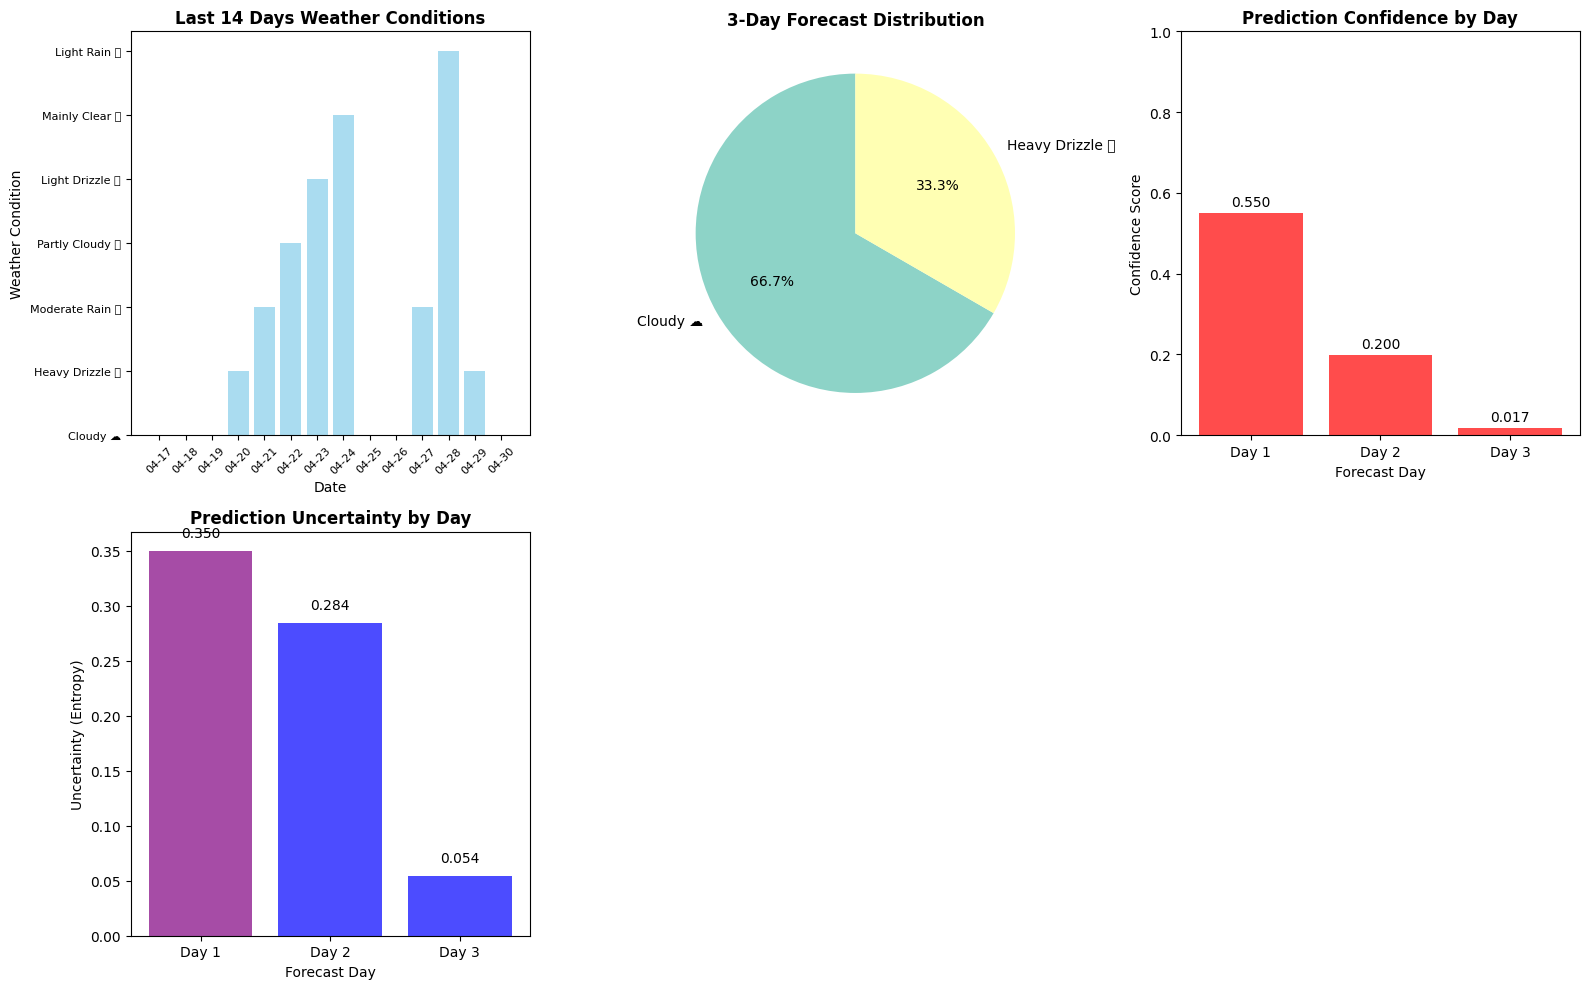


📊 TRANSFORMER PREDICTION SUMMARY:
Average Confidence: 0.256
Average Uncertainty: 0.229
Most Confident Day: Day 1 (0.550)
Least Confident Day: Day 3 (0.017)
Most Uncertain Day: Day 1 (0.350)
Least Uncertain Day: Day 3 (0.054)


In [39]:
def make_transformer_predictions_and_visualize(model, df):
    """Make Transformer predictions and create advanced visualizations"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    
    print("\n🔮 Making 3-day Transformer weather forecast...")
    print("-" * 50)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week (Transformer returns uncertainties too)
        predicted_conditions, confidence_scores, uncertainties = model.predict_next_week(recent_data)
        
        print("📅 3-Day Transformer Weather Forecast:")
        # Get last date in the dataset and generate next 4 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        # Enhanced prediction display with uncertainty
        print("┌" + "─" * 70 + "┐")
        print("│{:^70}│".format("TRANSFORMER WEATHER FORECAST"))
        print("├" + "─" * 15 + "┬" + "─" * 25 + "┬" + "─" * 12 + "┬" + "─" * 14 + "┤")
        print("│{:^15}│{:^25}│{:^12}│{:^14}│".format("Day (Date)", "Condition", "Confidence", "Uncertainty"))
        print("├" + "─" * 15 + "┼" + "─" * 25 + "┼" + "─" * 12 + "┼" + "─" * 14 + "┤")
        
        for (day, date), condition, confidence, uncertainty in zip(days_and_dates, predicted_conditions, confidence_scores, uncertainties):
            # Color coding based on confidence
            if confidence > 0.8:
                status = "🟢"  # High confidence
            elif confidence > 0.6:
                status = "🟡"  # Medium confidence
            else:
                status = "🔴"  # Low confidence
                
            day_short = day[:3]
            date_short = date[5:]  # MM-DD format
            condition_short = condition[:22] + "..." if len(condition) > 22 else condition
            
            print("│{}{:^14}│{:^25}│{:^12.3f}│{:^14.3f}│".format(
                status, f"{day_short} ({date_short})", condition_short, confidence, uncertainty))
        
        print("└" + "─" * 15 + "┴" + "─" * 25 + "┴" + "─" * 12 + "┴" + "─" * 14 + "┘")
        
        # Enhanced visualization with uncertainty
        plt.figure(figsize=(16, 10))
        
        # Plot 1: Recent actual weather conditions
        plt.subplot(2, 3, 1)
        recent_df = df[['date', 'weather_condition']].tail(14)
        recent_df['date'] = pd.to_datetime(recent_df['date'])
        bars = plt.bar(range(len(recent_df)), recent_df['weather_condition'].astype(str), 
                      color='skyblue', alpha=0.7)
        plt.xticks(range(len(recent_df)), 
                  recent_df['date'].dt.strftime('%m-%d'), rotation=45)
        plt.title('Last 14 Days Weather Conditions', fontsize=12, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        
        # Plot 2: Forecast distribution
        plt.subplot(2, 3, 2)
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        colors = plt.cm.Set3(range(len(forecast_counts)))
        wedges, texts, autotexts = plt.pie(forecast_counts.values, labels=forecast_counts.index, 
                                          autopct='%1.1f%%', colors=colors, startangle=90)
        plt.title('3-Day Forecast Distribution', fontsize=12, fontweight='bold')
        
        # Plot 3: Confidence scores over forecast days
        plt.subplot(2, 3, 3)
        days_short = [f"Day {i+1}" for i in range(3)]
        bars = plt.bar(days_short, confidence_scores, 
                      color=['green' if c > 0.8 else 'orange' if c > 0.6 else 'red' for c in confidence_scores],
                      alpha=0.7)
        plt.title('Prediction Confidence by Day', fontsize=12, fontweight='bold')
        plt.xlabel('Forecast Day')
        plt.ylabel('Confidence Score')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, conf in zip(bars, confidence_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{conf:.3f}', ha='center', va='bottom', fontsize=10)
        
        # Plot 4: Uncertainty analysis
        plt.subplot(2, 3, 4)
        bars = plt.bar(days_short, uncertainties,
                      color=['blue' if u < 0.3 else 'purple' if u < 0.6 else 'red' for u in uncertainties],
                      alpha=0.7)
        plt.title('Prediction Uncertainty by Day', fontsize=12, fontweight='bold')
        plt.xlabel('Forecast Day')
        plt.ylabel('Uncertainty (Entropy)')

        # Add value labels on bars
        for bar, unc in zip(bars, uncertainties):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{unc:.3f}', ha='center', va='bottom', fontsize=10)
        
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n📊 TRANSFORMER PREDICTION SUMMARY:")
        print(f"Average Confidence: {np.mean(confidence_scores):.3f}")
        print(f"Average Uncertainty: {np.mean(uncertainties):.3f}")
        print(f"Most Confident Day: Day {np.argmax(confidence_scores) + 1} ({max(confidence_scores):.3f})")
        print(f"Least Confident Day: Day {np.argmin(confidence_scores) + 1} ({min(confidence_scores):.3f})")
        print(f"Most Uncertain Day: Day {np.argmax(uncertainties) + 1} ({max(uncertainties):.3f})")
        print(f"Least Uncertain Day: Day {np.argmin(uncertainties) + 1} ({min(uncertainties):.3f})")
        
        return predicted_conditions, confidence_scores, uncertainties
        
    except Exception as e:
        print(f"❌ Transformer prediction error: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

# Usage:
predictions, confidences, uncertainties = make_transformer_predictions_and_visualize(best_model, df)


In [40]:
def evaluate_results(self, y_true, y_pred, history=None):
    """
    Comprehensive evaluation with class-tier analysis and visualizations
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import numpy as np
    
    print("\n" + "="*70)
    print("SLIDING WINDOW + REBALANCING RESULTS")
    print("="*70)
    
    # Overall accuracy
    overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    print(f"Overall Test Accuracy: {overall_acc:.4f}")
    
    # Daily accuracies
    daily_accuracies = []
    for day in range(self.forecast_horizon):
        day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
        daily_accuracies.append(day_acc)
        print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
    # Detailed classification report for Day 1
    print(f"\nDetailed Classification Report (Day 1):")
    print("-" * 70)
    target_names = self.label_encoder.classes_
    report = classification_report(y_true[:, 0], y_pred[:, 0], 
                                 target_names=target_names, 
                                 zero_division=0, 
                                 output_dict=True)
    print(classification_report(y_true[:, 0], y_pred[:, 0], 
                              target_names=target_names, 
                              zero_division=0))
    
    # Class-tier performance analysis
    print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
    print("="*70)
    
    for tier_name, class_list in [
        ("MINORITY", self.minority_classes),
        ("BALANCED", self.balanced_classes), 
        ("MAJORITY", self.majority_classes)
    ]:
        print(f"\n{tier_name} CLASSES:")
        print("-" * 40)
        tier_f1_scores = []
        tier_recalls = []
        tier_precisions = []
        
        for class_name in class_list:
            if class_name in report:
                metrics = report[class_name]
                f1 = metrics['f1-score']
                precision = metrics['precision']
                recall = metrics['recall']
                support = metrics['support']
                
                tier_f1_scores.append(f1)
                tier_recalls.append(recall)
                tier_precisions.append(precision)
                
                status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
        
        if tier_f1_scores:
            avg_f1 = np.mean(tier_f1_scores)
            avg_precision = np.mean(tier_precisions)
            avg_recall = np.mean(tier_recalls)
            print(f"\n  📊 {tier_name} AVERAGES:")
            print(f"     Precision: {avg_precision:.4f}")
            print(f"     Recall: {avg_recall:.4f}")
            print(f"     F1-Score: {avg_f1:.4f}")
    
    # Problem class identification
    print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
    print("-" * 50)
    struggling_classes = []
    for class_name in target_names:
        if class_name in report and report[class_name]['f1-score'] < 0.2:
            struggling_classes.append(class_name)
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
    
    if not struggling_classes:
        print("  🎉 No classes with F1 < 0.2!")
    
    # Success stories
    print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
    print("-" * 50)
    success_classes = []
    for class_name in target_names:
        if class_name in report and report[class_name]['f1-score'] > 0.5:
            success_classes.append(class_name)
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
    
    # Enhanced visualizations
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    
    # 1. Daily accuracies with trend line
    axes[0, 0].bar(range(1, self.forecast_horizon + 1), daily_accuracies, 
                   color=['#2E8B57' if acc > 0.7 else '#FF6B6B' if acc < 0.5 else '#4ECDC4' 
                          for acc in daily_accuracies])
    axes[0, 0].plot(range(1, self.forecast_horizon + 1), daily_accuracies, 
                    'ro-', linewidth=2, markersize=8, alpha=0.7)
    axes[0, 0].set_title('Accuracy by Forecast Day', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Day')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)
    for i, acc in enumerate(daily_accuracies):
        axes[0, 0].text(i+1, acc+0.02, f'{acc:.3f}', ha='center', fontweight='bold')
    
    # 2. Enhanced confusion matrix for Day 1
    cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
    mask = cm == 0
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, 
                ax=axes[0, 1], mask=mask, cbar_kws={'label': 'Count'})
    axes[0, 1].set_title('Confusion Matrix (Day 1)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')
    plt.setp(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
    plt.setp(axes[0, 1].get_yticklabels(), rotation=0)
    
    # 3. Class-tier F1 scores comparison
    tier_data = {'Tier': [], 'Class': [], 'F1-Score': [], 'Support': []}
    for tier_name, class_list in [("Minority", self.minority_classes),
                                  ("Balanced", self.balanced_classes), 
                                  ("Majority", self.majority_classes)]:
        for class_name in class_list:
            if class_name in report:
                tier_data['Tier'].append(tier_name)
                tier_data['Class'].append(class_name[:15] + '...' if len(class_name) > 15 else class_name)
                tier_data['F1-Score'].append(report[class_name]['f1-score'])
                tier_data['Support'].append(report[class_name]['support'])
    
    # Create tier comparison bar plot
    tier_colors = {'Minority': '#FF6B6B', 'Balanced': '#4ECDC4', 'Majority': '#2E8B57'}
    x_pos = np.arange(len(tier_data['Class']))
    colors = [tier_colors[tier] for tier in tier_data['Tier']]
    
    bars = axes[1, 0].bar(x_pos, tier_data['F1-Score'], color=colors, alpha=0.7)
    axes[1, 0].set_title('F1-Scores by Class Tier', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Classes')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(tier_data['Class'], rotation=45, ha='right')
    axes[1, 0].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Good (>0.5)')
    axes[1, 0].axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, label='Poor (<0.2)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, f1_score in zip(bars, tier_data['F1-Score']):
        if f1_score > 0.05:  # Only show label if bar is visible
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{f1_score:.2f}', ha='center', va='bottom', fontsize=8)
    
    # 4. Sample predictions vs actual (enhanced)
    sample_size = min(3, len(y_true))
    x_pos = np.arange(self.forecast_horizon)
    width = 0.35
    
    # Use the remaining subplot for the first sample
    axes[1, 1].bar(x_pos - width/2, y_true[0], width, label='Actual', alpha=0.7, color='skyblue')
    axes[1, 1].bar(x_pos + width/2, y_pred[0], width, label='Predicted', alpha=0.7, color='orange')
    axes[1, 1].set_title('Prediction vs Actual - Sample Sequence 1', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Day')
    axes[1, 1].set_ylabel('Weather Code')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([f'Day {d+1}' for d in x_pos])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 5. Prediction accuracy heatmap across all days
    day_class_accuracy = np.zeros((len(target_names), self.forecast_horizon))
    for day in range(self.forecast_horizon):
        for i, class_name in enumerate(target_names):
            class_mask = (y_true[:, day] == i)
            if np.sum(class_mask) > 0:
                day_class_accuracy[i, day] = np.mean(y_pred[class_mask, day] == y_true[class_mask, day])
    
    sns.heatmap(day_class_accuracy, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=[f'Day {d+1}' for d in range(self.forecast_horizon)],
                yticklabels=target_names, ax=axes[2, 0],
                cbar_kws={'label': 'Accuracy'})
    axes[2, 0].set_title('Class-wise Accuracy Across Forecast Days', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Forecast Day')
    axes[2, 0].set_ylabel('Weather Condition')
    plt.setp(axes[2, 0].get_yticklabels(), rotation=0)
    
    # 6. Training history (if available)
    if history is not None:
        axes[2, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
        axes[2, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
        axes[2, 1].set_title('Training History', fontsize=12, fontweight='bold')
        axes[2, 1].set_xlabel('Epoch')
        axes[2, 1].set_ylabel('Accuracy')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        
        # Add loss on secondary y-axis
        ax2 = axes[2, 1].twinx()
        ax2.plot(history.history['loss'], '--', color='red', alpha=0.7, label='Training Loss')
        ax2.plot(history.history['val_loss'], '--', color='orange', alpha=0.7, label='Validation Loss')
        ax2.set_ylabel('Loss')
        ax2.legend(loc='upper right')
    else:
        axes[2, 1].text(0.5, 0.5, 'No training history available', 
                       transform=axes[2, 1].transAxes, ha='center', va='center', 
                       fontsize=14, style='italic')
        axes[2, 1].set_title('Training History', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Enhanced sample predictions display
    print(f"\n📊 DETAILED SAMPLE PREDICTIONS:")
    print("="*70)
    sample_size = min(3, len(y_true))
    for i in range(sample_size):
        actual_conditions = self.label_encoder.inverse_transform(y_true[i])
        pred_conditions = self.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\nSequence {i+1}:")
        print("-" * 50)
        matches = 0
        for day in range(self.forecast_horizon):
            match_status = "✅" if actual_conditions[day] == pred_conditions[day] else "❌"
            if actual_conditions[day] == pred_conditions[day]:
                matches += 1
            print(f"  Day {day+1}: {match_status} Actual='{actual_conditions[day]}' | Predicted='{pred_conditions[day]}'")
        
        sequence_accuracy = matches / self.forecast_horizon
        print(f"  📈 Sequence Accuracy: {sequence_accuracy:.2%} ({matches}/{self.forecast_horizon})")
    
    # Summary metrics
    print(f"\n🎯 FINAL PERFORMANCE SUMMARY:")
    print("="*70)
    
    minority_f1_scores = []
    balanced_f1_scores = []
    majority_f1_scores = []
    
    for class_name in self.minority_classes:
        if class_name in report:
            minority_f1_scores.append(report[class_name]['f1-score'])
    
    for class_name in self.balanced_classes:
        if class_name in report:
            balanced_f1_scores.append(report[class_name]['f1-score'])
            
    for class_name in self.majority_classes:
        if class_name in report:
            majority_f1_scores.append(report[class_name]['f1-score'])
    
    print(f"📊 Overall Test Accuracy: {overall_acc:.4f}")
    print(f"📊 Average Daily Accuracy: {np.mean(daily_accuracies):.4f}")
    if minority_f1_scores:
        print(f"🎯 Average Minority Class F1: {np.mean(minority_f1_scores):.4f}")
    if balanced_f1_scores:
        print(f"⚖️  Average Balanced Class F1: {np.mean(balanced_f1_scores):.4f}")
    if majority_f1_scores:
        print(f"📈 Average Majority Class F1: {np.mean(majority_f1_scores):.4f}")
    
    # Model complexity info
    if hasattr(self, 'model') and self.model is not None:
        total_params = self.model.count_params()
        print(f"🔧 Model Parameters: {total_params:,}")
    
    return overall_acc, daily_accuracies, history, y_true, y_pred

# This will work with the enhanced method
overall_acc, daily_accuracies, history, y_true, y_pred = best_model.evaluate_transformer_results(y_true, y_pred, history)



TIME SERIES TRANSFORMER + REBALANCING RESULTS({model_type})
Overall Test Accuracy: 0.8696
Day 1 accuracy: 0.8711
Day 2 accuracy: 0.8775
Day 3 accuracy: 0.8603

Detailed Classification Report (Day 1):
----------------------------------------------------------------------
                    precision    recall  f1-score   support

      Clear Sky ☀️       0.69      0.56      0.62       249
         Cloudy ☁️       0.83      0.85      0.84      1299
   Heavy Drizzle 🌧       0.95      0.98      0.97       253
      Heavy Rain 🌧       0.95      1.00      0.98        20
   Light Drizzle 🌦       0.89      0.88      0.88       932
      Light Rain 🌦       0.97      0.98      0.97       514
Moderate Drizzle 🌧       0.94      0.98      0.96       759
   Moderate Rain 🌧       0.97      0.98      0.98       365
  Partly Clear 🌤/⛅       0.72      0.69      0.70       620

          accuracy                           0.87      5011
         macro avg       0.88      0.88      0.88      5011
      

In [41]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    """
    Enhanced display of actual vs predicted weather conditions with comprehensive analysis
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import Counter
    
    print("🌤️  ENHANCED WEATHER CONDITION PREDICTIONS")
    print("=" * 80)
    
    sample_size = min(num_samples, len(y_true))
    
    # Class-tier mapping for enhanced analysis
    class_tier_map = {}
    for class_name in model.minority_classes:
        class_tier_map[class_name] = "Minority"
    for class_name in model.balanced_classes:
        class_tier_map[class_name] = "Balanced"
    for class_name in model.majority_classes:
        class_tier_map[class_name] = "Majority"
    
    # Track prediction patterns
    prediction_analysis = {
        'perfect_sequences': 0,
        'good_sequences': 0,  # >=75% accuracy
        'poor_sequences': 0,  # <50% accuracy
        'minority_successes': 0,
        'minority_attempts': 0,
        'transition_predictions': []
    }
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)
        
        # Enhanced table format with confidence indicators
        print(f"{'Day':>4} | {'Actual Weather':^25} | {'Predicted Weather':^25} | {'Match':^6} | {'Tier':^8}")
        print("-" * 85)
        
        matches = 0
        sequence_has_minority = False
        
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            
            # Get class tier for actual condition
            tier = class_tier_map.get(actual, "Unknown")
            tier_color = "🔴" if tier == "Minority" else "🟡" if tier == "Balanced" else "🟢"
            
            # Track minority class performance
            if tier == "Minority":
                sequence_has_minority = True
                prediction_analysis['minority_attempts'] += 1
                if actual == predicted:
                    prediction_analysis['minority_successes'] += 1
            
            if actual == predicted:
                matches += 1
                
            # Truncate long weather names for display
            actual_display = actual[:23] + ".." if len(actual) > 25 else actual
            pred_display = predicted[:23] + ".." if len(predicted) > 25 else predicted
            
            print(f"{day+1:>4} | {actual_display:^25} | {pred_display:^25} | {match:^6} | {tier_color}{tier[:7]:^7}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 85)
        
        # Sequence quality assessment
        if accuracy == 1.0:
            quality = "🎯 PERFECT"
            prediction_analysis['perfect_sequences'] += 1
        elif accuracy >= 0.75:
            quality = "✅ GOOD"
            prediction_analysis['good_sequences'] += 1
        elif accuracy >= 0.5:
            quality = "⚠️  FAIR"
        else:
            quality = "❌ POOR"
            prediction_analysis['poor_sequences'] += 1
        
        minority_indicator = " 🔴 (Contains Minority)" if sequence_has_minority else ""
        print(f"Sequence Quality: {quality} - {matches}/{model.forecast_horizon} ({accuracy:.1%}){minority_indicator}")
        
        # Analyze weather transitions
        if model.forecast_horizon > 1:
            transitions = []
            for day in range(model.forecast_horizon - 1):
                if actual_conditions[day] != actual_conditions[day + 1]:
                    transition_actual = f"{actual_conditions[day]} → {actual_conditions[day + 1]}"
                    transition_pred = f"{pred_conditions[day]} → {pred_conditions[day + 1]}"
                    transition_correct = transition_actual == transition_pred
                    transitions.append((transition_actual, transition_pred, transition_correct))
            
            if transitions:
                print("🔄 Weather Transitions:")
                for j, (t_actual, t_pred, t_correct) in enumerate(transitions):
                    status = "✅" if t_correct else "❌"
                    print(f"   {status} Day {j+1}→{j+2}: {t_actual[:40]}...")
                    if not t_correct:
                        print(f"      Predicted: {t_pred[:40]}...")
    
    # Enhanced overall statistics
    print(f"\n📊 COMPREHENSIVE PREDICTION ANALYSIS:")
    print("=" * 80)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"📈 Basic Metrics:")
    print(f"   Total Predictions: {total_predictions:,}")
    print(f"   Correct Predictions: {correct_predictions:,}")
    print(f"   Overall Accuracy: {overall_accuracy:.3f} ({overall_accuracy:.1%})")
    
    # Sequence quality distribution
    total_sequences = sample_size
    print(f"\n🎯 Sequence Quality Distribution (from {total_sequences} samples):")
    print(f"   Perfect Sequences (100%): {prediction_analysis['perfect_sequences']} ({prediction_analysis['perfect_sequences']/total_sequences:.1%})")
    print(f"   Good Sequences (≥75%): {prediction_analysis['good_sequences']} ({prediction_analysis['good_sequences']/total_sequences:.1%})")
    print(f"   Poor Sequences (<50%): {prediction_analysis['poor_sequences']} ({prediction_analysis['poor_sequences']/total_sequences:.1%})")
    
    # Minority class performance
    if prediction_analysis['minority_attempts'] > 0:
        minority_success_rate = prediction_analysis['minority_successes'] / prediction_analysis['minority_attempts']
        print(f"\n🔴 Minority Class Performance:")
        print(f"   Minority Predictions: {prediction_analysis['minority_attempts']}")
        print(f"   Minority Successes: {prediction_analysis['minority_successes']}")
        print(f"   Minority Success Rate: {minority_success_rate:.3f} ({minority_success_rate:.1%})")
    
    # Per-day accuracy with trend analysis
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 50)
    daily_accuracies = []
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        daily_accuracies.append(day_accuracy)
        
        # Trend indicator
        if day > 0:
            trend = "📈" if day_accuracy > daily_accuracies[day-1] else "📉" if day_accuracy < daily_accuracies[day-1] else "➡️"
        else:
            trend = "🎯"
        
        quality_indicator = "🟢" if day_accuracy > 0.8 else "🟡" if day_accuracy > 0.6 else "🔴"
        print(f"   Day {day+1}: {quality_indicator} {day_accuracy:.3f} ({day_accuracy:.1%}) - {day_correct}/{day_total} {trend}")
    
    # Accuracy trend analysis
    if len(daily_accuracies) > 1:
        trend_slope = (daily_accuracies[-1] - daily_accuracies[0]) / (len(daily_accuracies) - 1)
        if abs(trend_slope) < 0.01:
            trend_desc = "📊 Stable accuracy across forecast horizon"
        elif trend_slope > 0:
            trend_desc = f"📈 Improving accuracy (+{trend_slope:.3f} per day)"
        else:
            trend_desc = f"📉 Declining accuracy ({trend_slope:.3f} per day)"
        print(f"\n   {trend_desc}")
    
    # Class-wise prediction distribution
    print(f"\n🌈 PREDICTION DISTRIBUTION BY CLASS TIER:")
    print("-" * 60)
    
    # Analyze all predictions by tier
    all_actual = y_true.flatten()
    all_pred = y_pred.flatten()
    
    tier_stats = {"Minority": {"correct": 0, "total": 0}, 
                  "Balanced": {"correct": 0, "total": 0}, 
                  "Majority": {"correct": 0, "total": 0}}
    
    for actual_idx, pred_idx in zip(all_actual, all_pred):
        actual_class = model.label_encoder.inverse_transform([actual_idx])[0]
        tier = class_tier_map.get(actual_class, "Unknown")
        
        if tier in tier_stats:
            tier_stats[tier]["total"] += 1
            if actual_idx == pred_idx:
                tier_stats[tier]["correct"] += 1
    
    for tier, stats in tier_stats.items():
        if stats["total"] > 0:
            accuracy = stats["correct"] / stats["total"]
            icon = "🔴" if tier == "Minority" else "🟡" if tier == "Balanced" else "🟢"
            print(f"   {icon} {tier:8} Classes: {accuracy:.3f} ({accuracy:.1%}) - {stats['correct']}/{stats['total']}")
    
    # Most confused predictions
    print(f"\n🤔 MOST COMMON PREDICTION ERRORS:")
    print("-" * 50)
    
    error_pairs = []
    for actual_idx, pred_idx in zip(all_actual, all_pred):
        if actual_idx != pred_idx:
            actual_class = model.label_encoder.inverse_transform([actual_idx])[0]
            pred_class = model.label_encoder.inverse_transform([pred_idx])[0]
            error_pairs.append((actual_class, pred_class))
    
    if error_pairs:
        error_counter = Counter(error_pairs)
        top_errors = error_counter.most_common(5)
        
        for i, ((actual, predicted), count) in enumerate(top_errors, 1):
            actual_tier = class_tier_map.get(actual, "Unknown")
            pred_tier = class_tier_map.get(predicted, "Unknown")
            
            actual_short = actual[:20] + "..." if len(actual) > 23 else actual
            pred_short = predicted[:20] + "..." if len(predicted) > 23 else predicted
            
            print(f"   {i}. {actual_short} → {pred_short}")
            print(f"      ({actual_tier} → {pred_tier}) - {count} times")
    else:
        print("   🎉 No prediction errors found!")
    
    # Confidence assessment (if available)
    if hasattr(model, 'model') and model.model is not None:
        print(f"\n🎲 MODEL COMPLEXITY:")
        print("-" * 30)
        total_params = model.model.count_params()
        print(f"   Total Parameters: {total_params:,}")
        if hasattr(model, 'd_model'):
            print(f"   Model Type: Transformer (d_model={model.d_model})")
        else:
            print(f"   Model Type: LSTM/Dense Network")
    
    return {
        'overall_accuracy': overall_accuracy,
        'daily_accuracies': daily_accuracies,
        'sequence_quality': prediction_analysis,
        'tier_performance': tier_stats,
        'top_errors': error_counter.most_common(5) if error_pairs else []
    }

# Enhanced usage with return value for further analysis:
results = show_weather_predictions(best_model, y_true, y_pred, num_samples=3)
print(f"Analysis complete. Overall accuracy: {results['overall_accuracy']:.1%}")

🌤️  ENHANCED WEATHER CONDITION PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------
 Day |      Actual Weather       |     Predicted Weather     | Match  |   Tier  
-------------------------------------------------------------------------------------
   1 |         Cloudy ☁️         |         Cloudy ☁️         |   ✅    | 🟢Majorit
   2 |         Cloudy ☁️         |         Cloudy ☁️         |   ✅    | 🟢Majorit
   3 |     Partly Clear 🌤/⛅      |         Cloudy ☁️         |   ❌    | 🟢Majorit
-------------------------------------------------------------------------------------
Sequence Quality: ⚠️  FAIR - 2/3 (66.7%)
🔄 Weather Transitions:
   ❌ Day 1→2: Cloudy ☁️ → Partly Clear 🌤/⛅...
      Predicted: Cloudy ☁️ → Cloudy ☁️...

📅 Test Sequence 2:
------------------------------------------------------------
 Day |      Actual Weather       |     Predicted Weather     | Match  |   Tier  
------------------------------------------------------------------

In [42]:
import os
import pickle
import joblib
from datetime import datetime
import json

def save_transformer_model(model, model_name="Transformer Model", save_dir="saved_models"):
    """
    Save the complete Transformer model including weights, architecture, and preprocessing components
    """
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras/TensorFlow model (architecture + weights) - using new Keras format
        model_path = f"{model_folder}/transformer_model.keras"
        model.model.save(model_path)
        print(f"✅ Transformer model saved: transformer_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler (if exists)
        if hasattr(model, 'scaler') and model.scaler is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save training data (X_train, y_train) if available for retraining
        if hasattr(model, 'X_train') and hasattr(model, 'y_train'):
            training_data = {
                'X_train': model.X_train,
                'y_train': model.y_train
            }
            training_path = f"{model_folder}/training_data.pkl"
            with open(training_path, 'wb') as f:
                pickle.dump(training_data, f)
            print(f"✅ Training data saved: training_data.pkl")
        
        # 5. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_columns', []),
            'target_column': getattr(model, 'target_column', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'TimeSeriesTransformerModel',
            'framework': 'TensorFlow/Keras',
            # Transformer-specific parameters
            'embed_dim': getattr(model, 'embed_dim', 64),
            'num_heads': getattr(model, 'num_heads', 4),
            'ff_dim': getattr(model, 'ff_dim', 128),
            'num_layers': getattr(model, 'num_layers', 2),
            'dropout_rate': getattr(model, 'dropout_rate', 0.1)
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 6. Save the entire model object (for easy loading)
        full_model_path = f"{model_folder}/full_model.pkl"
        # Create a copy without the keras model to avoid serialization issues
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)  # Remove keras model as it's saved separately
        # Remove large numpy arrays to reduce file size
        large_arrays = ['X_train', 'y_train', 'X_test', 'y_test', 'X_val', 'y_val']
        for arr_name in large_arrays:
            model_copy.pop(arr_name, None)
        
        with open(full_model_path, 'wb') as f:
            pickle.dump(model_copy, f)
        print(f"✅ Full model object saved: full_model.pkl")
        
        # 7. Create a README file with instructions
        readme_content = f"""# {model_name}

Saved on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Model Details:
- Model Type: Time Series Transformer Weather Forecasting Model
- Sequence Length: {model.sequence_length} days
- Forecast Horizon: {model.forecast_horizon} days
- Number of Classes: {len(model.label_encoder.classes_)}
- Weather Conditions: {', '.join(model.label_encoder.classes_)}
- Embedding Dimension: {getattr(model, 'embed_dim', 64)}
- Number of Attention Heads: {getattr(model, 'num_heads', 4)}
- Feed Forward Dimension: {getattr(model, 'ff_dim', 128)}

## Files:
- `transformer_model.keras`: TensorFlow/Keras Transformer model architecture and weights
- `label_encoder.pkl`: Label encoder for weather conditions
- `scaler.pkl`: Feature scaler (if used)
- `model_config.json`: Model configuration and metadata
- `full_model.pkl`: Complete model object (without Keras model)
- `training_data.pkl`: Training data for potential retraining
- `README.md`: This file

## Loading Instructions:
```python
# Load using the load_transformer_model function
model = load_transformer_model('{model_folder}')

# Or load components manually:
from tensorflow.keras.models import load_model
import pickle

# Load Transformer model
transformer_model = load_model('{model_folder}/transformer_model.keras')

# Load label encoder
with open('{model_folder}/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
```

## Model Performance:
Add your performance metrics here after evaluation.
"""
        
        readme_path = f"{model_folder}/README.md"
        with open(readme_path, 'w', encoding='utf-8') as f:
            f.write(readme_content)
        print(f"✅ README file created: README.md")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        print(f"🤖 Architecture: Transformer with {getattr(model, 'num_heads', 4)} attention heads")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        import traceback
        print(f"Error details: {traceback.format_exc()}")
        return None

def load_transformer_model(model_folder):
    """
    Load a saved Transformer model
    """
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")
        
        # Load Keras model
        from tensorflow.keras.models import load_model
        transformer_model = load_model(f"{model_folder}/transformer_model.keras")
        
        # Load label encoder
        with open(f"{model_folder}/label_encoder.pkl", 'rb') as f:
            label_encoder = pickle.load(f)
        
        # Load scaler if exists
        scaler = None
        scaler_path = f"{model_folder}/scaler.pkl"
        if os.path.exists(scaler_path):
            scaler = joblib.load(scaler_path)
        
        # Load training data if exists
        training_data = None
        training_path = f"{model_folder}/training_data.pkl"
        if os.path.exists(training_path):
            with open(training_path, 'rb') as f:
                training_data = pickle.load(f)
        
        # Load full model object
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)
        
        print("✅ All components loaded successfully!")
        print(f"🤖 Model type: {config['model_type']}")
        print(f"📊 Classes: {len(config['class_names'])}")
        
        return {
            'transformer_model': transformer_model,
            'label_encoder': label_encoder,
            'scaler': scaler,
            'config': config,
            'model_dict': model_dict,
            'training_data': training_data
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        import traceback
        print(f"Error details: {traceback.format_exc()}")
        return None

def reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel):
    """
    Reconstruct the complete TimeSeriesTransformerModel from loaded components
    """
    try:
        # Create a new instance of the model class
        config = loaded_components['config']
        
        # You'll need to pass the original dataframe or create a dummy one
        # This is a limitation - you might want to save essential data features too
        print("⚠️  Note: You need to provide the original dataframe or create a compatible one")
        
        # Create model instance with saved parameters
        model = TimeSeriesTransformerModel(
            df=None,  # You'll need to provide this
            sequence_length=config['sequence_length'],
            forecast_horizon=config['forecast_horizon']
        )
        
        # Restore the saved components
        model.model = loaded_components['transformer_model']
        model.label_encoder = loaded_components['label_encoder']
        model.scaler = loaded_components['scaler']
        
        # Restore other attributes from model_dict
        for key, value in loaded_components['model_dict'].items():
            if not hasattr(model, key):
                setattr(model, key, value)
        
        # Restore training data if available
        if loaded_components['training_data']:
            model.X_train = loaded_components['training_data']['X_train']
            model.y_train = loaded_components['training_data']['y_train']
        
        print("✅ Transformer model reconstructed successfully!")
        return model
        
    except Exception as e:
        print(f"❌ Error reconstructing model: {str(e)}")
        return None

# Usage Examples:

# Save your transformer model
model_folder = save_transformer_model(best_model, "WeatherTransformerVersion2")

"""
# Load your model later
loaded_components = load_transformer_model(model_folder)

# Reconstruct the complete model (you need your TimeSeriesTransformerModel class)
reconstructed_model = reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel)

# Or use individual components
transformer_keras_model = loaded_components['transformer_model']
label_encoder = loaded_components['label_encoder']
scaler = loaded_components['scaler']
config = loaded_components['config']
"""

💾 Saving 'WeatherTransformerVersion2' to: saved_models/WeatherTransformerVersion2_20250701_153550
✅ Transformer model saved: transformer_model.keras
✅ Label encoder saved: label_encoder.pkl
✅ Model configuration saved: model_config.json
❌ Error saving model: Can't pickle local object 'Oracle.__init__.<locals>.<lambda>'
Error details: Traceback (most recent call last):
  File "C:\Users\AHLEM\AppData\Local\Temp\ipykernel_11932\3250991116.py", line 90, in save_transformer_model
    pickle.dump(model_copy, f)
AttributeError: Can't pickle local object 'Oracle.__init__.<locals>.<lambda>'



"\n# Load your model later\nloaded_components = load_transformer_model(model_folder)\n\n# Reconstruct the complete model (you need your TimeSeriesTransformerModel class)\nreconstructed_model = reconstruct_transformer_model(loaded_components, TimeSeriesTransformerModel)\n\n# Or use individual components\ntransformer_keras_model = loaded_components['transformer_model']\nlabel_encoder = loaded_components['label_encoder']\nscaler = loaded_components['scaler']\nconfig = loaded_components['config']\n"